# Глава 9. Дифференцирование и интегрирование

### Пономарев Т. Е. 5130901/30201

## Упражнение 9.2
Цель этого упражнения — изучить влияние операторов `diff` и `differentiate` на сигнал.  Создайте треугольную волну и постройте её график.  Примените оператор `diff` и постройте график результата.  Вычислите спектр треугольной волны, примените `differentiate` и постройте график результата.  Преобразуйте спектр обратно в волну и постройте ее график.  Есть ли различия между влиянием операторов `diff` и `differentiate` на эту волну?

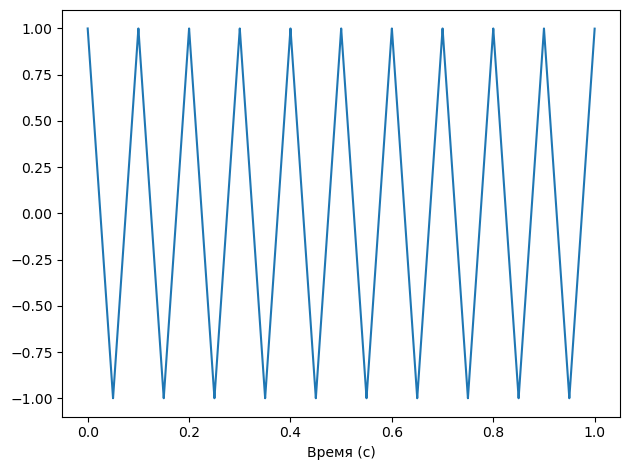

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from thinkdsp import PI2, decorate, TriangleSignal, SquareSignal, SawtoothSignal
import scipy.signal

# треугольный сигнал
in_wave = TriangleSignal(freq = 10).make_wave(duration = 1, framerate = 44100)
in_wave.plot()
decorate(xlabel = "Время (с)")

Дифференциал треугольной волны представляет собой прямоугольную волну, что объясняет, почему гармоники в прямоугольной волне затухают по закону $1/f$, в отличие от треугольной волны, где затухание происходит по закону $1/f^2$.

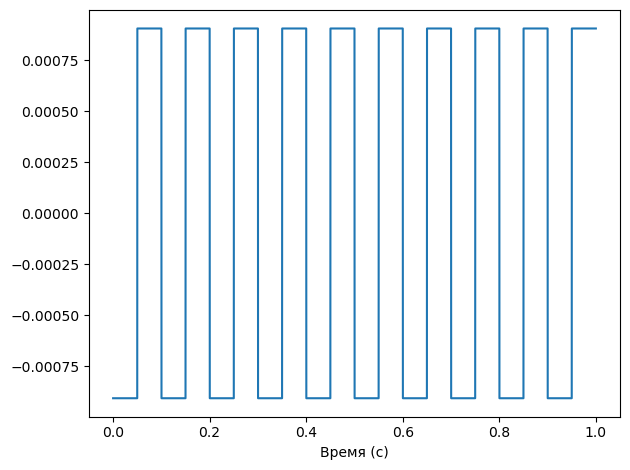

In [2]:
out_wave = in_wave.diff()
out_wave.plot()
decorate(xlabel = "Время (с)")

При вычислении спектральной производной вокруг точек разрыва возникает «колебание»: https://en.wikipedia.org/wiki/Ringing_(signal)

С математической точки зрения проблема заключается в том, что производная треугольной волны не определена в вершинах треугольника.

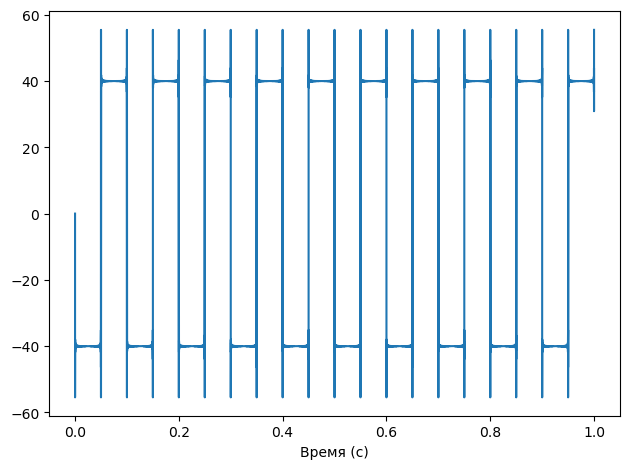

In [3]:
out_wave_2 = in_wave.make_spectrum().differentiate().make_wave()
out_wave_2.plot()
decorate(xlabel = "Время (с)")

## Упражнение 9.3
Цель этого упражнения — изучить влияние операторов `cumsum` и `integrate` на сигнал.  Создайте прямоугольную волну и постройте ее график.  Примените оператор `cumsum` и постройте график результата.  Вычислите спектр прямоугольной волны, примените `integrate` и постройте график результата.  Преобразуйте спектр обратно в волну и постройте ее график.  Есть ли различия между влиянием операторов `cumsum` и `integrate` на эту волну?

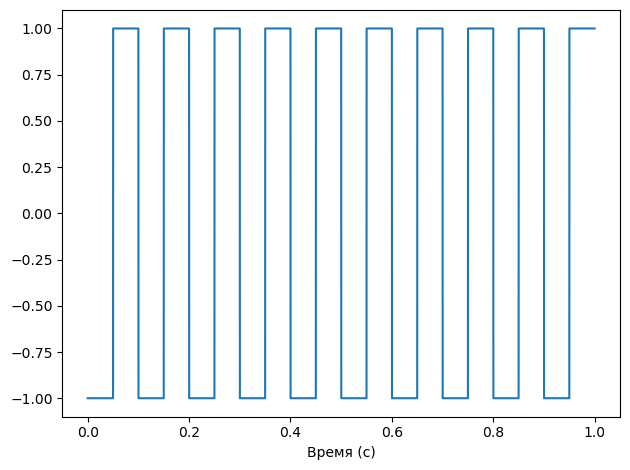

In [4]:
# прямоугольный сигнал
in_wave = SquareSignal(freq = 10).make_wave(duration = 1, framerate = 44100)
in_wave.plot()
decorate(xlabel = "Время (с)")

Сумма квадратичных импульсов представляет собой треугольную волну.

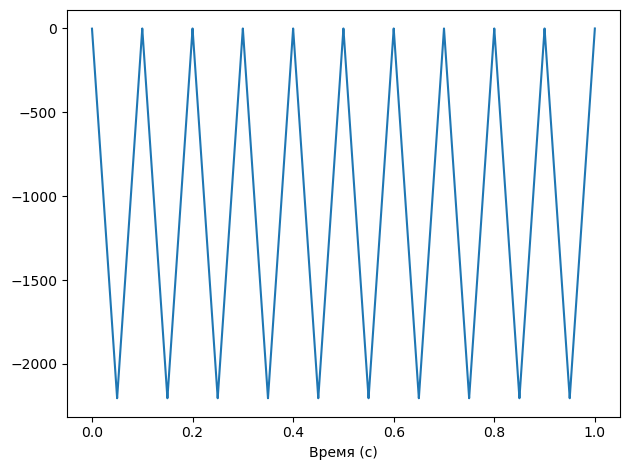

In [5]:
out_wave = in_wave.cumsum()
out_wave.plot()
decorate(xlabel = "Время (с)")

Спектральный интеграл также представляет собой треугольную волну, хотя амплитуда у него совсем другая.

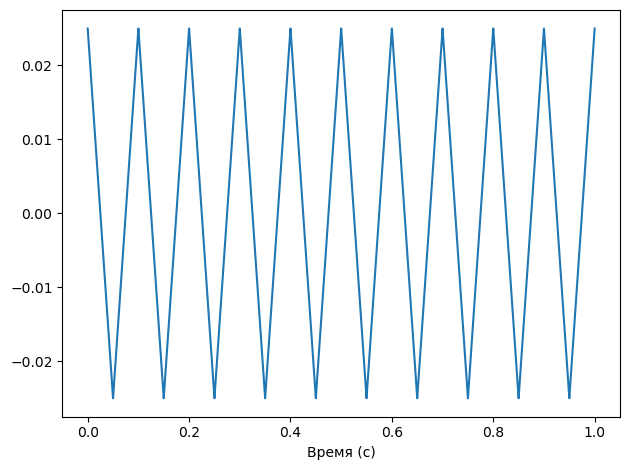

In [6]:
spectrum = in_wave.make_spectrum().integrate()
spectrum.hs[0] = 0
out_wave_2 = spectrum.make_wave()
out_wave_2.plot()
decorate(xlabel = "Время (с)")

Если устранить смещение и нормализовать эти две волны, они будут похожи.

np.float64(0.0009070294784579991)

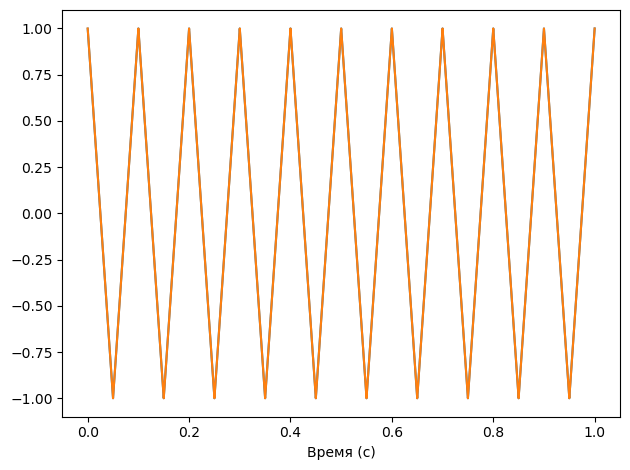

In [8]:
out_wave.unbias()
out_wave.normalize()
out_wave_2.normalize()
out_wave.plot()
out_wave_2.plot()
decorate(xlabel = "Время (с)")
out_wave.max_diff(out_wave_2)

## Упражнение 9.4
Цель этого упражнения — изучить эффект от двукратного применения функции `integrate`.  Создайте пилообразную волну, вычислите её спектр, а затем дважды примените к ней функцию `integrate`.  Постройте график полученной волны и её спектра.  Какова математическая форма этой волны?  Почему она напоминает синусоиду? 

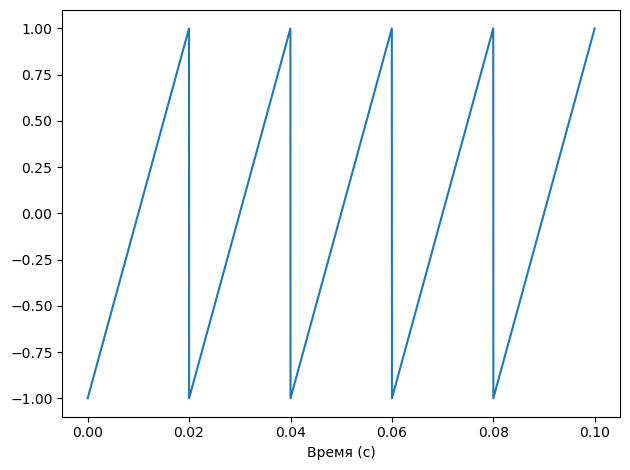

In [29]:
# пилообразный сигнал
in_wave = SawtoothSignal(freq = 50).make_wave(duration = 0.1, framerate = 44100)
in_wave.plot()
decorate(xlabel = "Время (с)")

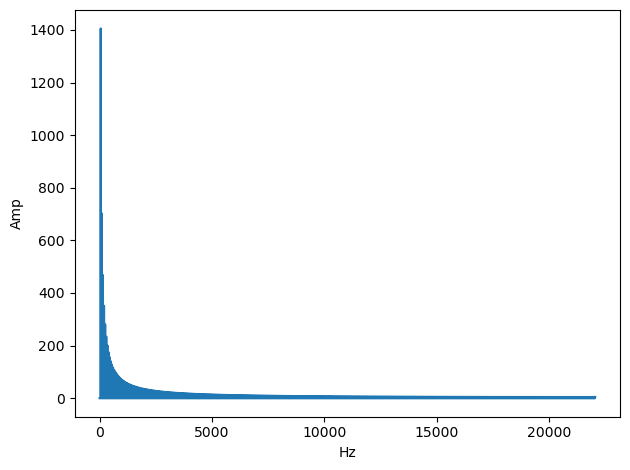

In [30]:
spectrum = in_wave.make_spectrum()
spectrum.plot()
decorate(xlabel = "Hz", ylabel = "Amp")

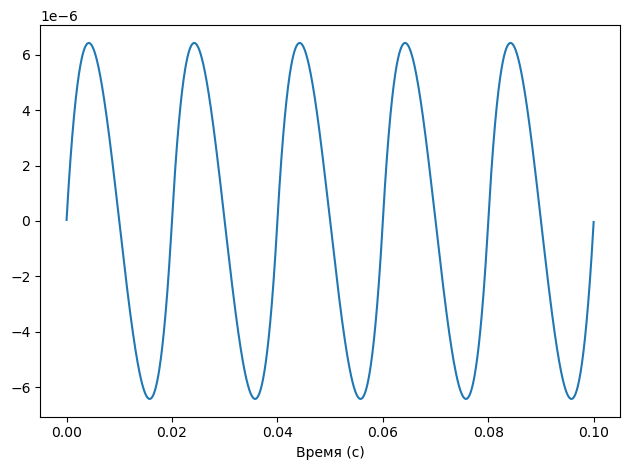

In [31]:
spectrum_2 = spectrum.integrate().integrate()
spectrum_2.hs[0] = 0
out_wave_2 = spectrum_2.make_wave()
out_wave_2.plot()
decorate(xlabel = "Время (с)")

На данном этапе результат всё больше и больше напоминает синусоиду.  Причина в том, что интегрирование действует как фильтр низких частот.  На данный момент отфильтровано всё, кроме основной частоты, как показано на спектре ниже:

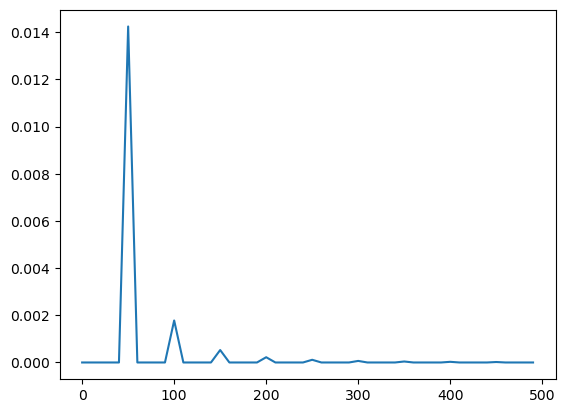

In [32]:
out_wave_2.make_spectrum().plot(high = 500)

## Упражнение 9.5
Цель этого упражнения — изучить влияние второй разности и второй производной.  Создайте объект `CubicSignal`, который определён в пакете `thinkdsp`.  Вычислите вторую разность, дважды применив функцию `diff`.  Как выглядит результат?  Вычислите вторую производную, дважды применив функцию `differentiate`.  Выглядит ли результат так же?

Постройте графики фильтров, соответствующих второй разности и второй производной, и сравните их.  Подсказка: чтобы получить фильтры в одном масштабе, используйте волну с частотой кадров 1.

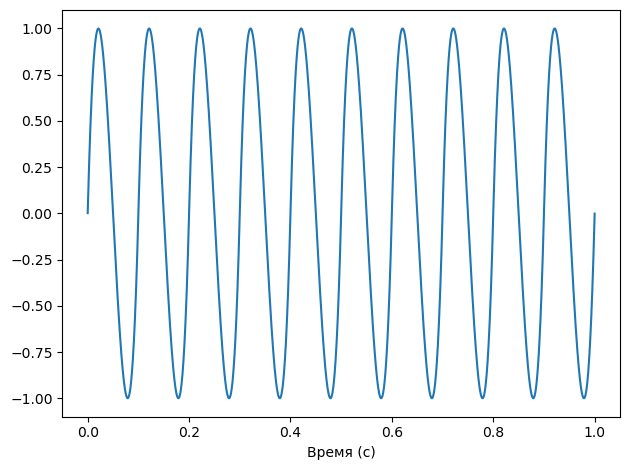

In [34]:
from thinkdsp import CubicSignal 

# кубический сигнал
in_wave = CubicSignal(freq = 10).make_wave(duration = 1, framerate = 44100)
in_wave.plot()
decorate(xlabel = "Время (с)")

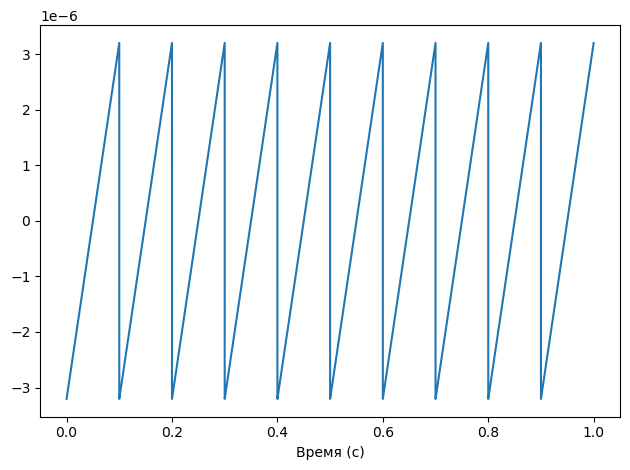

In [35]:
out_wave = in_wave.diff().diff()
out_wave.plot()
decorate(xlabel = "Время (с)")

При двукратном дифференцировании мы получаем пилообразную кривую с некоторым резонансом.  И снова проблема заключается в том, что производная параболического сигнала не определена в этих точках.

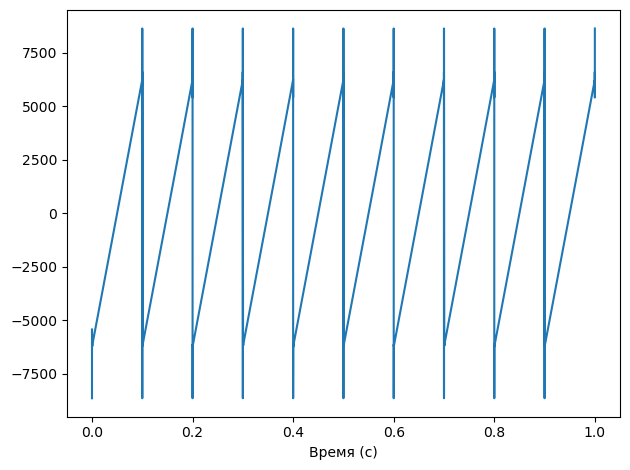

In [36]:
out_wave_2 = in_wave.make_spectrum().differentiate().differentiate().make_wave()
out_wave_2.plot()
decorate(xlabel = "Время (с)")

Окно второй разности имеет форму -1, 2, -1.  Вычислив ДФТ этого окна, мы сможем найти соответствующий фильтр.

А для второй производной мы можем найти соответствующий фильтр, вычислив фильтр первой производной и возведя его в квадрат.

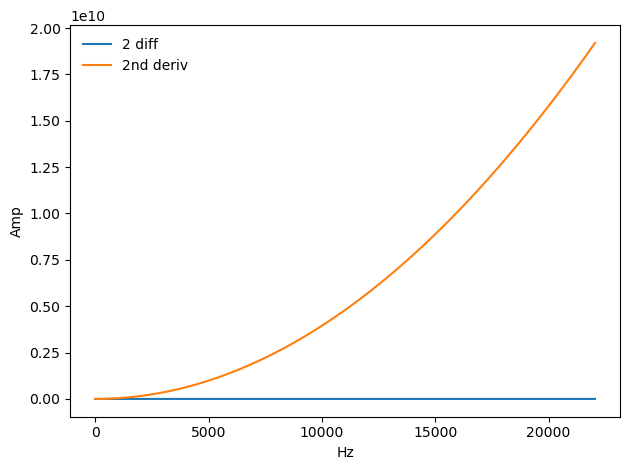

In [40]:
from thinkdsp import zero_pad
from thinkdsp import Wave

diff_window = np.array([-1.0, 2.0, -1.0])
padded = zero_pad(diff_window, len(in_wave))
diff_wave = Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()

deriv_filter = in_wave.make_spectrum()
deriv_filter.hs = (PI2 * 1j * deriv_filter.fs)**2


diff_filter.plot(label='2 diff')
deriv_filter.plot(label='2nd deriv')
decorate(xlabel='Hz', ylabel='Amp')

Оба являются фильтрами высоких частот, которые усиливают компоненты самых высоких частот. Вторая производная имеет параболическую форму, поэтому она усиливает самые высокие частоты сильнее всего. Вторая разность является хорошим приближением ко второй производной только на самых низких частотах, а затем значительно отклоняется от неё.